In [1]:
# Cell 0: imports & config
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

repo_root = Path("/Users/toddywang/Documents/VsCodeProjects/xmltoexp")
data_root = repo_root / "MazurkaBL-master"
beat_time_dir = data_root / "beat_time"

mazurka_id = "M06-1"
beat_time_file = beat_time_dir / f"{mazurka_id}beat_time.csv"

print("beat_time_file:", beat_time_file)


beat_time_file: /Users/toddywang/Documents/VsCodeProjects/xmltoexp/MazurkaBL-master/beat_time/M06-1beat_time.csv


In [2]:
# Cell 1: load + tempo curves
def load_beat_time(file_path: Path):
    df = pd.read_csv(file_path)
    meta_cols = {"Unnamed: 0", "measure_number", "beat_number"}
    performer_cols = [c for c in df.columns if c not in meta_cols]
    beat_index = np.arange(len(df), dtype=int)
    return df, performer_cols, beat_index

def compute_tempo_curves(df, performer_cols, smooth_window=3, bpm_range=(0, 5000), clip_max=600):
    n_beats = len(df)
    tempo_arrays = {}

    lo, hi = bpm_range
    for col in performer_cols:
        times = pd.to_numeric(df[col], errors="coerce").to_numpy(dtype=float)
        dt = np.diff(times, prepend=np.nan)
        tempo = 60.0 / dt

        # drop invalid or non-positive intervals
        invalid = (dt <= 0) | (~np.isfinite(tempo))
        tempo[invalid] = np.nan

        s = pd.Series(tempo)
        s = s.where((s > lo) & (s < hi))
        s = s.interpolate("linear", limit_direction="both")

        # smooth + clip
        s = s.rolling(window=smooth_window, center=True, min_periods=1).mean()
        s = s.clip(upper=clip_max)

        tempo_arrays[col] = s.to_numpy()

    return tempo_arrays

df_bt, performer_cols, beat_index = load_beat_time(beat_time_file)
tempo_arrays = compute_tempo_curves(df_bt, performer_cols, smooth_window=3)

print("beats:", len(beat_index))
print("performers:", len(tempo_arrays))


beats: 337
performers: 34


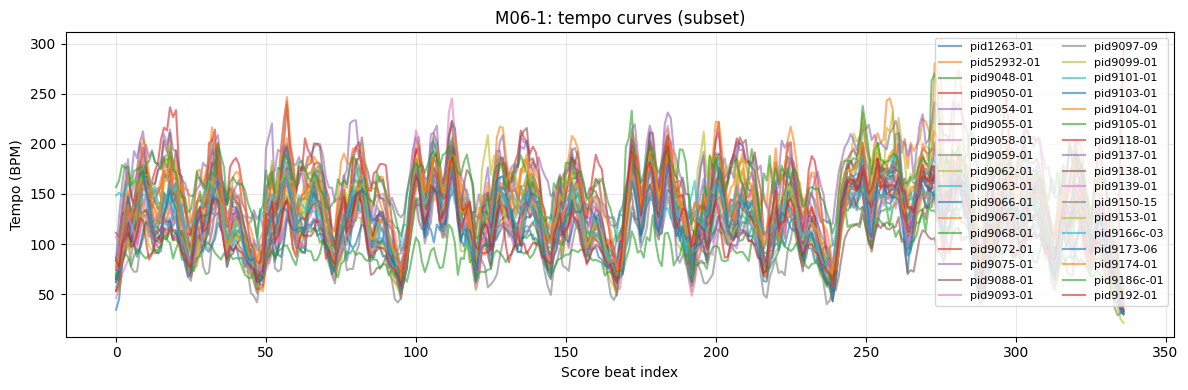

In [3]:
# Cell 2: overlay plot (random subset)
def plot_overlay_tempos(tempo_arrays, n=5, max_beats=None, seed=0):
    if not tempo_arrays:
        print("tempo_arrays is empty.")
        return
    names = list(tempo_arrays.keys())
    if n is not None and n < len(names):
        rng = np.random.default_rng(seed)
        names = list(rng.choice(names, size=n, replace=False))

    plt.figure(figsize=(12, 4))
    for nm in names:
        curve = tempo_arrays[nm]
        if max_beats is not None:
            curve = curve[:max_beats]
        plt.plot(curve, alpha=0.6, label=nm)
    plt.xlabel("Score beat index")
    plt.ylabel("Tempo (BPM)")
    plt.title(f"{mazurka_id}: tempo curves (subset)")
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

plot_overlay_tempos(tempo_arrays, n=34, max_beats=400)


In [4]:
# Cell 3: boundary detection (same idea as tempocurve.ipynb)
def group_analysis_new(tempo_curve, ws, plot=False, return_pro=False):
    tempo = np.asarray(tempo_curve, dtype=float)
    n = len(tempo)
    ws = int(ws)
    if ws <= 1 or n == 0:
        return np.array([], dtype=int) if not return_pro else (np.array([], dtype=int), tempo * 0)

    # sliding RMS (zero padding)
    if ws % 2 == 1:
        pad_left = (ws - 1) // 2
        pad_right = ws - 1 - pad_left
    else:
        pad_left = ws // 2
        pad_right = ws - pad_left

    padded = np.pad(tempo, (pad_left, pad_right), mode="constant", constant_values=0.0)
    pro = np.zeros(n, dtype=float)

    for i in range(n):
        window = padded[i:i + ws]
        nonzero = window != 0
        if np.any(nonzero):
            pro[i] = np.sqrt(np.sum(window[nonzero] ** 2) / nonzero.sum())
        else:
            pro[i] = 0.0

    # valleys on pro = peaks on -pro
    min_width = int(np.ceil(ws / 2))
    peaks, _ = find_peaks(-pro, distance=min_width)

    if len(peaks) == 0:
        return np.array([], dtype=int) if not return_pro else (np.array([], dtype=int), pro)

    # refine: local minimum on original tempo
    locs = []
    half = (ws - 1) // 2 if (ws % 2 == 1) else ws // 2
    for p in peaks:
        left = max(0, p - half)
        right = min(n - 1, p + half)
        segment = tempo[left:right + 1]
        if segment.size == 0:
            continue
        locs.append(left + int(np.argmin(segment)))

    locs = np.array(sorted(set(locs)), dtype=int)

    if plot:
        fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 6))
        axes[0].plot(pro, label="RMS (pro)")
        axes[0].set_ylabel("RMS")
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(tempo, label="tempo")
        axes[1].stem(locs, tempo[locs], linefmt="C1-", markerfmt="C1o", basefmt=" ", label="boundaries")
        axes[1].set_xlabel("Score beat index")
        axes[1].set_ylabel("Tempo")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    return (locs, pro) if return_pro else locs

def boundaries_to_mask(n_beats, boundary_indices):
    mask = np.zeros(n_beats, dtype=int)
    boundary_indices = np.asarray(boundary_indices, dtype=int)
    boundary_indices = boundary_indices[(boundary_indices >= 0) & (boundary_indices < n_beats)]
    mask[boundary_indices] = 1
    return mask

ws = 12
boundary_locs_dict = {}
boundary_masks_dict = {}

for name, curve in tempo_arrays.items():
    locs, _ = group_analysis_new(curve, ws=ws, plot=False, return_pro=True)
    boundary_locs_dict[name] = locs
    boundary_masks_dict[name] = boundaries_to_mask(len(curve), locs)

print("done, example locs:", list(boundary_locs_dict.items())[:1])


done, example locs: [('pid1263-01', array([ 25,  47,  73,  85,  95, 120, 145, 157, 169, 192, 217, 229, 239,
       252, 264, 276, 288, 313]))]


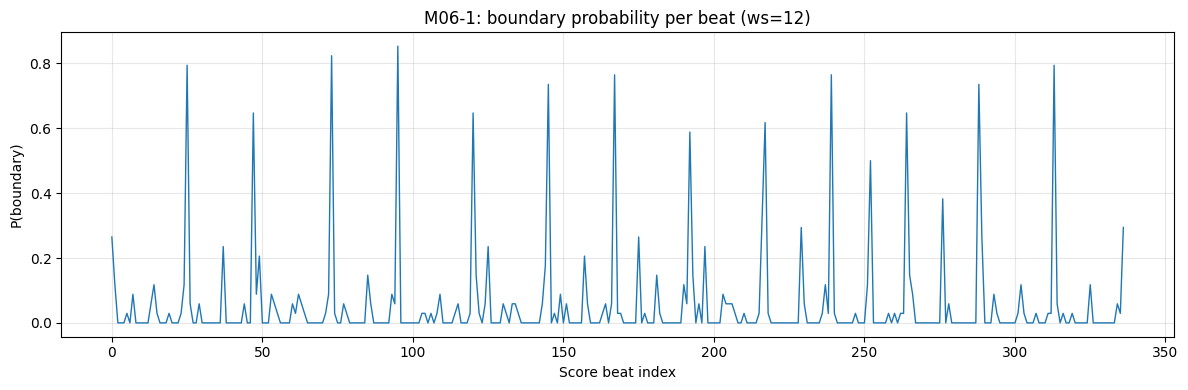

In [5]:
# Cell 4: boundary probability curve
names = list(tempo_arrays.keys())
mask_mat = np.stack([boundary_masks_dict[nm] for nm in names], axis=0)
boundary_ratio = mask_mat.mean(axis=0)

plt.figure(figsize=(12, 4))
plt.plot(np.arange(len(boundary_ratio)), boundary_ratio, linewidth=1)
plt.xlabel("Score beat index")
plt.ylabel("P(boundary)")
plt.title(f"{mazurka_id}: boundary probability per beat (ws={ws})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [7]:
# Cell 5: save (optional)
out_path = repo_root / "out" / f"mazurka_{mazurka_id}_boundary_prob.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)

pd.DataFrame({
    "beat_index": np.arange(len(boundary_ratio)),
    "boundary_probability": boundary_ratio
}).to_csv(out_path, index=False)

print("saved:", out_path)


saved: /Users/toddywang/Documents/VsCodeProjects/xmltoexp/out/mazurka_M06-1_boundary_prob.csv


In [6]:
# Cell 6: batch over all Mazurkas
all_results = {}
summary_rows = []

for file_path in sorted(beat_time_dir.glob("*beat_time.csv")):
    mazurka_id = file_path.name.replace("beat_time.csv", "")
    df_bt, performer_cols, beat_index = load_beat_time(file_path)
    tempo_arrays = compute_tempo_curves(df_bt, performer_cols, smooth_window=3)

    # boundaries
    boundary_masks_dict = {}
    for name, curve in tempo_arrays.items():
        locs, _ = group_analysis_new(curve, ws=ws, plot=False, return_pro=True)
        boundary_masks_dict[name] = boundaries_to_mask(len(curve), locs)

    names = list(tempo_arrays.keys())
    mask_mat = np.stack([boundary_masks_dict[nm] for nm in names], axis=0)
    boundary_ratio = mask_mat.mean(axis=0)

    all_results[mazurka_id] = {
        "tempo_arrays": tempo_arrays,
        "boundary_ratio": boundary_ratio,
        "n_beats": len(boundary_ratio),
        "n_performers": len(tempo_arrays),
    }

    summary_rows.append({
        "mazurka_id": mazurka_id,
        "n_beats": len(boundary_ratio),
        "n_performers": len(tempo_arrays),
        "boundary_mean": float(np.nanmean(boundary_ratio)),
    })

print("processed:", len(all_results), "mazurkas")


processed: 46 mazurkas


In [9]:
# Cell 7: optional batch save
out_dir = repo_root / "out" / "mazurka_boundary_probs"
out_dir.mkdir(parents=True, exist_ok=True)

for mazurka_id, info in all_results.items():
    out_path = out_dir / f"{mazurka_id}_boundary_prob.csv"
    pd.DataFrame({
        "beat_index": np.arange(info["n_beats"]),
        "boundary_probability": info["boundary_ratio"]
    }).to_csv(out_path, index=False)

summary_path = out_dir / "mazurka_summary.csv"
pd.DataFrame(summary_rows).to_csv(summary_path, index=False)

print("saved:", out_dir)


saved: /Users/toddywang/Documents/VsCodeProjects/xmltoexp/out/mazurka_boundary_probs


In [9]:
# 分层

# Cell 4: hierarchical boundary detection (block hierarchy, thesis/MATLAB-style)

def _pad_to_multiple(x, m):
    x = np.asarray(x, dtype=float).reshape(-1)
    pad = (-len(x)) % m
    if pad == 0:
        return x
    return np.concatenate([x, np.zeros(pad, dtype=float)])

def group_analysis_hierarchy(tempo_curve, str_vec, eps=1e-12, enforce_nested=True):
    """
    Thesis/MATLAB-style hierarchy:
      - level 1 groups beats into blocks of size str_vec[0]
      - level i>=2 computes eng2 per block: RMS(norm) - std(norm), finds valleys on eng2
      - trace from top-level valleys down to beat indices
    Returns:
      results_raw: (L, N) bool, row t means boundaries traced from top=t (1..L)
      levels: dict with keys 1..L -> np.array of beat indices
              if enforce_nested=True: level L is coarsest, level 1 is finest and nested.
    """
    tempo = np.asarray(tempo_curve, dtype=float).reshape(-1)
    N = len(tempo)
    str_vec = np.asarray(str_vec, dtype=int).reshape(-1)
    L = len(str_vec)
    if N == 0:
        return np.zeros((L, 0), dtype=bool), {l: np.array([], dtype=int) for l in range(1, L+1)}

    avg = np.nanmean(tempo)
    if not np.isfinite(avg) or avg == 0:
        avg = 1.0

    # 1-indexed containers (match MATLAB mental model)
    energy  = [None] * (L + 1)
    energy2 = [None] * (L + 1)
    valleys = [None] * (L + 1)

    # Level 1: reshape beats into blocks
    s1 = int(str_vec[0])
    pad_raw  = _pad_to_multiple(tempo, s1)
    pad_norm = _pad_to_multiple(tempo / avg, s1)
    energy[1]  = pad_raw.reshape((s1, -1), order="F")   # MATLAB reshape is column-major
    energy2[1] = pad_norm.reshape((s1, -1), order="F")

    # Valleys at level 1: minima on original tempo (beat-level)
    v1, _ = find_peaks(-tempo)
    valleys[1] = v1 + 1  # store 1-based indices

    # Build higher levels
    for i in range(2, L + 1):
        t_eng = energy[i - 1].copy()
        t_eng[t_eng == 0] = np.nan

        # eng2 over blocks (one value per block / column)
        t_norm = t_eng / avg
        eng2 = np.sqrt(np.nanmean(t_norm ** 2, axis=0)) - np.nanstd(t_norm, axis=0)

        vi, _ = find_peaks(-eng2)     # valleys on block sequence
        valleys[i] = vi + 1           # 1-based block indices (of level i-1)

        # reshape eng2 into next level matrices for trace
        si = int(str_vec[i - 1])
        eng2_pad = _pad_to_multiple(eng2, si)
        energy[i]  = _pad_to_multiple(np.sqrt(np.nanmean(t_eng ** 2, axis=0)), si).reshape((si, -1), order="F")
        energy2[i] = eng2_pad.reshape((si, -1), order="F")

    # Trace from each top level to beats
    results_raw = np.zeros((L, N), dtype=bool)

    for top in range(L, 0, -1):
        roots = valleys[top]
        if roots is None or len(roots) == 0:
            continue

        trace = np.zeros((top, len(roots)), dtype=int)
        trace[0, :] = roots  # 1-based indices

        for rj in range(len(roots)):
            for i in range(2, top + 1):
                lvl = top + 1 - i   # energy2[lvl] used at this step (MATLAB indexing)
                parent_col = trace[i - 2, rj]  # 1-based column index
                colvec = energy2[lvl][:, parent_col - 1]
                # choose row with minimal eng2 within the parent block
                row = int(np.nanargmin(colvec)) + 1  # 1-based
                trace[i - 1, rj] = int(str_vec[lvl - 1]) * (parent_col - 1) + row

        beats_1b = trace[top - 1, :]
        beats_0b = beats_1b - 1
        beats_0b = beats_0b[(beats_0b >= 0) & (beats_0b < N)]
        results_raw[top - 1, beats_0b] = True

    # Convert to per-level boundary sets
    level_sets = {l: np.where(results_raw[l-1])[0] for l in range(1, L+1)}  # raw (not necessarily nested)

    # Enforce nested coarse-to-fine if requested:
    # Define B_l = union_{t=l..L} raw(t), so level L is coarsest, level 1 is finest and nested.
    if enforce_nested:
        cum = np.zeros(N, dtype=bool)
        nested = {}
        for l in range(L, 0, -1):
            cum |= results_raw[l-1]
            nested[l] = np.where(cum)[0]
        level_sets = nested

    return results_raw, level_sets


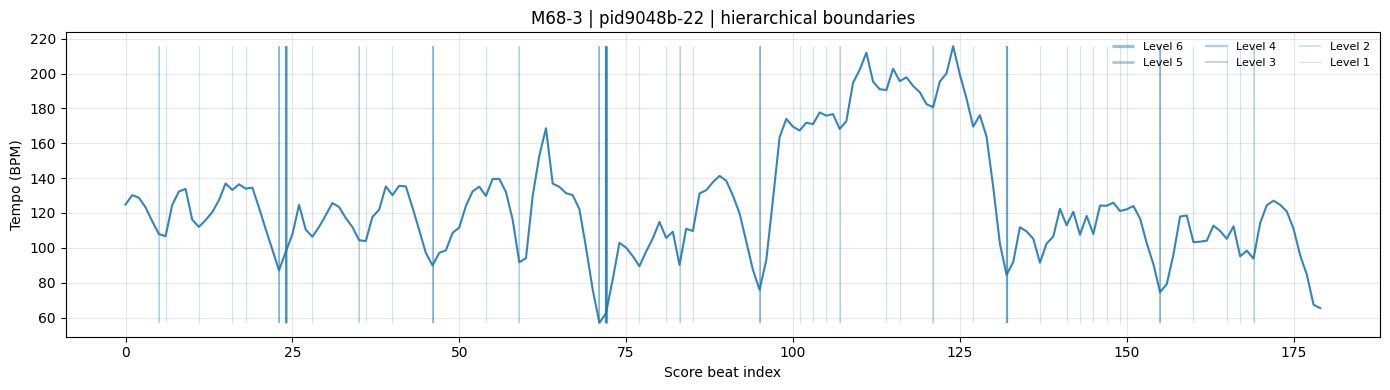

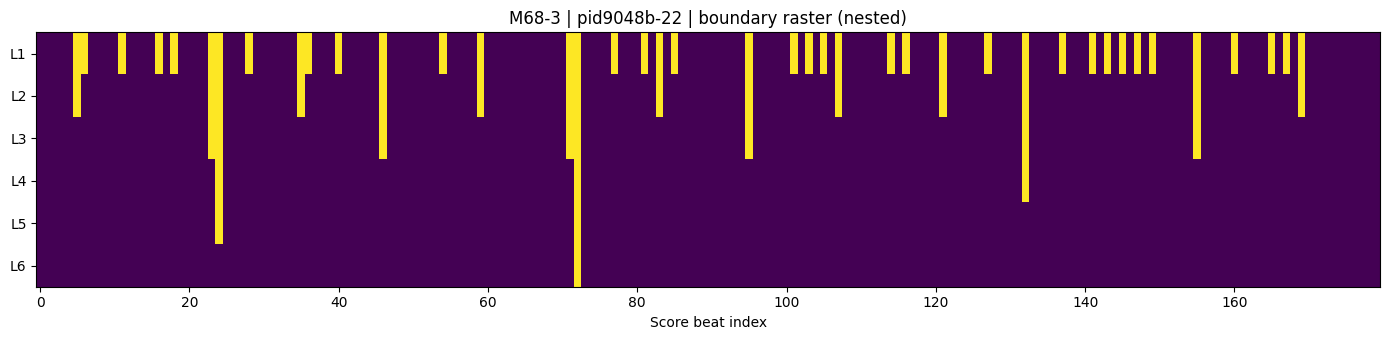

In [47]:
# Cell 5: visualize hierarchical boundaries for one performer

def plot_hierarchy_on_tempo(tempo_curve, level_sets, title="", max_beats=400):
    tempo = np.asarray(tempo_curve, dtype=float)
    n = min(len(tempo), max_beats)
    tempo = tempo[:n]

    L = max(level_sets.keys())

    fig, ax = plt.subplots(1, 1, figsize=(14, 4))
    ax.plot(tempo, alpha=0.9)
    ax.set_title(title)
    ax.set_xlabel("Score beat index")
    ax.set_ylabel("Tempo (BPM)")
    ax.grid(alpha=0.3)

    # draw vertical lines for each level (coarse=top level)
    # to keep it readable: higher levels thicker
    for l in range(L, 0, -1):
        xs = level_sets[l]
        xs = xs[xs < n]
        if len(xs) == 0:
            continue
        ax.vlines(xs, ymin=np.nanmin(tempo), ymax=np.nanmax(tempo),
                  alpha=0.15 + 0.05*(l), linewidth=0.5 + 0.3*l, label=f"Level {l}")

    ax.legend(ncol=3, fontsize=8, frameon=False)
    plt.tight_layout()
    plt.show()

def plot_hierarchy_raster(level_sets, n_beats, title="", max_beats=400):
    n = min(n_beats, max_beats)
    L = max(level_sets.keys())
    mat = np.zeros((L, n), dtype=int)
    for l in range(1, L+1):
        xs = level_sets[l]
        xs = xs[xs < n]
        mat[l-1, xs] = 1

    plt.figure(figsize=(14, 3.5))
    plt.imshow(mat, aspect="auto", interpolation="nearest")
    plt.yticks(np.arange(L), [f"L{l}" for l in range(1, L+1)])
    plt.xlabel("Score beat index")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# run on one performer
str_vec = [3, 2, 2, 2, 2, 2]  # 6 levels
names = list(tempo_arrays.keys())
one_name = names[2] 
curve = tempo_arrays[one_name]

results_raw, level_sets = group_analysis_hierarchy(curve, str_vec, enforce_nested=True)

plot_hierarchy_on_tempo(curve, level_sets, title=f"{mazurka_id} | {one_name} | hierarchical boundaries", max_beats=400)
plot_hierarchy_raster(level_sets, n_beats=len(curve), title=f"{mazurka_id} | {one_name} | boundary raster (nested)", max_beats=400)


In [39]:
# Cell 7: aggregate hierarchical boundaries across performers

str_vec = [3,2,2,2,2,2]   # 6 levels
L = len(str_vec)

performer_names = list(tempo_arrays.keys())
n_perf = len(performer_names)
n_beats = len(next(iter(tempo_arrays.values())))

# counts[l-1, i] = number of performers whose Level l has a boundary at beat i
counts = np.zeros((L, n_beats), dtype=int)

# (可选) 保存每个演奏者每一层的边界集合，方便以后分析
hier_boundary_dict = {}

for nm in performer_names:
    curve = tempo_arrays[nm]
    _, level_sets = group_analysis_hierarchy(curve, str_vec, enforce_nested=True)  # nested levels
    hier_boundary_dict[nm] = level_sets
    for l in range(1, L+1):
        idx = np.asarray(level_sets[l], dtype=int)
        idx = idx[(idx >= 0) & (idx < n_beats)]
        counts[l-1, idx] += 1

freq = counts / max(n_perf, 1)

print("done. performers:", n_perf, "beats:", n_beats)
print("example: level-6 total boundaries per performer (avg):",
      counts[5].sum() / max(n_perf, 1))


done. performers: 42 beats: 180
example: level-6 total boundaries per performer (avg): 0.8809523809523809


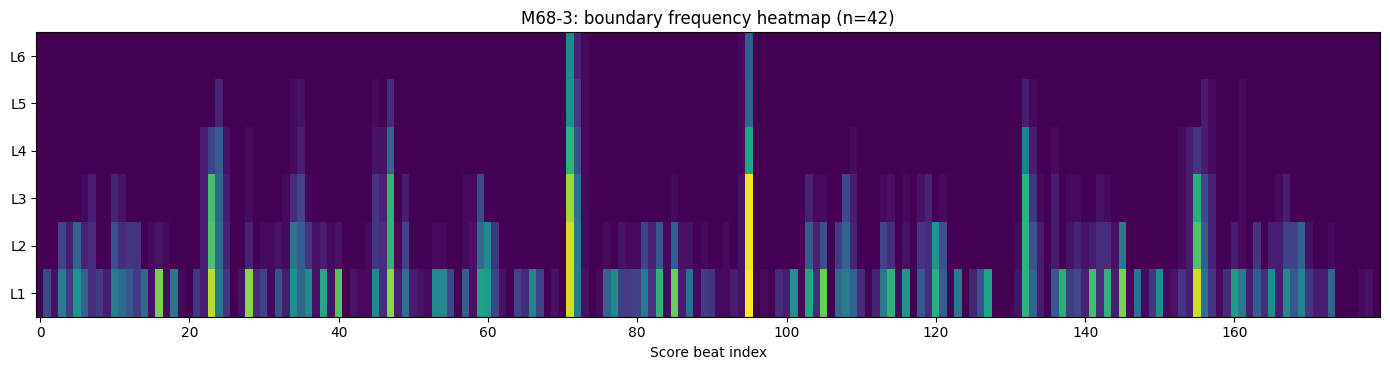

In [40]:
# Cell 8: heatmap of boundary frequency across performers

def plot_boundary_heatmap(freq, title="", max_beats=400, show_levels_top_down=True):
    L, N = freq.shape
    n = min(N, max_beats)
    mat = freq[:, :n]
    if show_levels_top_down:
        # 把 Level 6 放上面更符合“粗→细”的视觉习惯
        mat = mat[::-1, :]
        ylabels = [f"L{l}" for l in range(L, 0, -1)]
    else:
        ylabels = [f"L{l}" for l in range(1, L+1)]

    plt.figure(figsize=(14, 3.8))
    plt.imshow(mat, aspect="auto", interpolation="nearest")
    plt.yticks(np.arange(L), ylabels)
    plt.xlabel("Score beat index")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_boundary_heatmap(freq, title=f"{mazurka_id}: boundary frequency heatmap (n={n_perf})", max_beats=400)


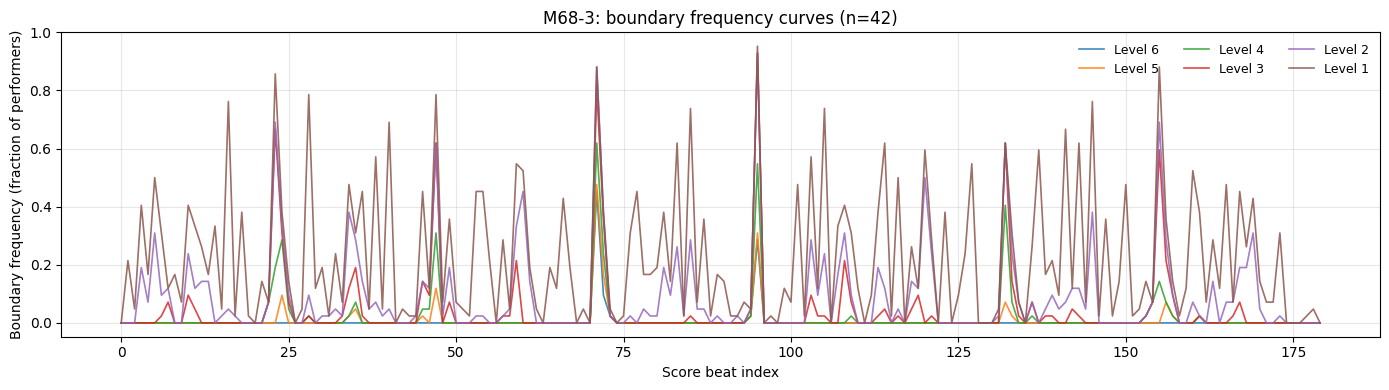

In [41]:
# Cell 9: overlay curves of boundary frequency per level

def plot_level_frequency_curves(freq, title="", max_beats=400):
    L, N = freq.shape
    n = min(N, max_beats)

    plt.figure(figsize=(14, 4))
    for l in range(L, 0, -1):   # L..1（粗到细）
        y = freq[l-1, :n]
        plt.plot(y, linewidth=1.2, alpha=0.85, label=f"Level {l}")
    plt.xlabel("Score beat index")
    plt.ylabel("Boundary frequency (fraction of performers)")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend(ncol=3, fontsize=9, frameon=False)
    plt.tight_layout()
    plt.show()

plot_level_frequency_curves(freq, title=f"{mazurka_id}: boundary frequency curves (n={n_perf})", max_beats=400)


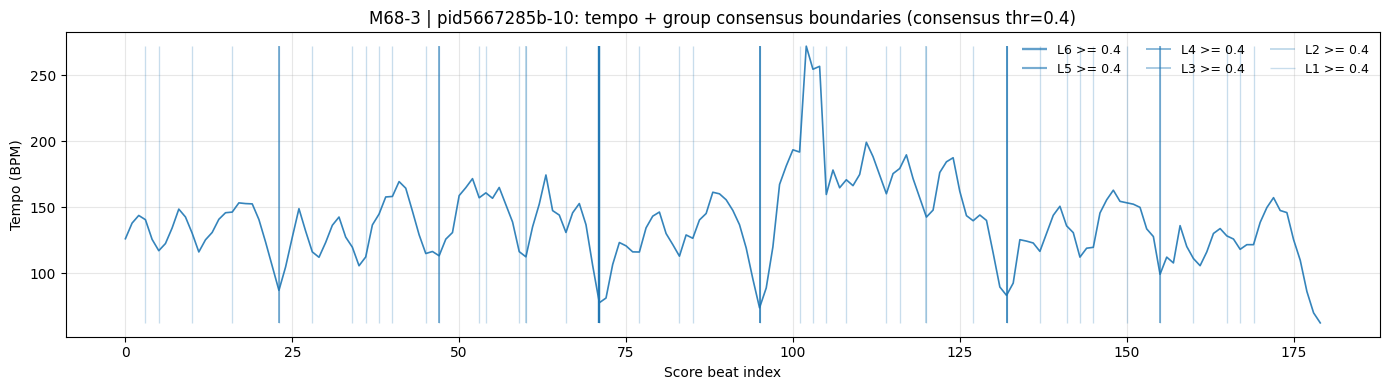

In [46]:
# Cell 10: overlay group-consensus boundaries on one performer's tempo

def plot_consensus_on_tempo(tempo_curve, freq, title="", max_beats=400, thr=0.3):
    tempo = np.asarray(tempo_curve, dtype=float)
    n = min(len(tempo), max_beats)
    tempo = tempo[:n]

    L = freq.shape[0]
    y0, y1 = np.nanmin(tempo), np.nanmax(tempo)

    fig, ax = plt.subplots(1, 1, figsize=(14, 4))
    ax.plot(tempo, alpha=0.9, linewidth=1.2)
    ax.set_title(title + f" (consensus thr={thr})")
    ax.set_xlabel("Score beat index")
    ax.set_ylabel("Tempo (BPM)")
    ax.grid(alpha=0.3)

    # 粗层更显眼
    for l in range(L, 0, -1):
        xs = np.where(freq[l-1, :n] >= thr)[0]
        if xs.size == 0:
            continue
        lw = 0.8 + 0.9*(l/L)
        alpha = 0.15 + 0.55*(l/L)
        ax.vlines(xs, ymin=y0, ymax=y1, linewidth=lw, alpha=alpha, label=f"L{l} >= {thr}")

    ax.legend(ncol=3, fontsize=9, frameon=False)
    plt.tight_layout()
    plt.show()

# pick one performer
nm = list(tempo_arrays.keys())[1]
plot_consensus_on_tempo(
    tempo_arrays[nm], freq,
    title=f"{mazurka_id} | {nm}: tempo + group consensus boundaries",
    max_beats=400, thr=0.4
)
